# Package 1 — Exploration & cleaning

Goal: understand the data before trusting it. Nothing gets modeled today.

In [1]:
import pandas as pd

df = pd.read_csv("../data/funnel_marketing_data.csv")
df.shape

(3500, 19)

In [2]:
df.head()

,ad_budget,num_leads,leads_answered,leads_not_answered,followup_1,followup_2,followup_3,followup_4,followup_5,not_closed,closed,calls_to_closed,calls_to_not_closed,customer_acquisition_cost,ltv_months,purchased,upsell,cumulative_profit,referred
0,2500,36,24,12,19,14,11,10,7,5,2,2,4,1250,38.0,1,0,20777.0,No
1,15000,98,55,43,43,32,26,25,18,14,4,5,3,3750,10.0,1,0,3531.0,Yes
2,6000,60,35,25,27,19,16,15,11,7,4,5,3,1500,12.0,1,0,3967.0,No
3,4000,48,32,16,25,18,15,13,9,4,5,3,3,800,28.0,1,0,15048.0,Yes
4,1500,25,14,11,10,8,6,6,4,4,0,0,4,0,3.0,0,0,0.0,No


In [3]:
df.isna().sum()

ad_budget                     0
num_leads                     0
leads_answered                0
leads_not_answered            0
followup_1                    0
followup_2                    0
followup_3                    0
followup_4                    0
followup_5                    0
not_closed                    0
closed                        0
calls_to_closed               0
calls_to_not_closed           0
customer_acquisition_cost     0
ltv_months                    4
purchased                     0
upsell                        0
cumulative_profit            29
referred                      0
dtype: int64

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ad_budget                  3500 non-null   int64  
 1   num_leads                  3500 non-null   int64  
 2   leads_answered             3500 non-null   int64  
 3   leads_not_answered         3500 non-null   int64  
 4   followup_1                 3500 non-null   int64  
 5   followup_2                 3500 non-null   int64  
 6   followup_3                 3500 non-null   int64  
 7   followup_4                 3500 non-null   int64  
 8   followup_5                 3500 non-null   int64  
 9   not_closed                 3500 non-null   int64  
 10  closed                     3500 non-null   int64  
 11  calls_to_closed            3500 non-null   int64  
 12  calls_to_not_closed        3500 non-null   int64  
 13  customer_acquisition_cost  3500 non-null   int64  
 14  ltv

## Missing values — conclusion

Only two columns have gaps: `ltv_months` (4 rows) and `cumulative_profit` (29 rows).
Both are **targets** for later tasks (Package 2 and Package 6 respectively), so the
affected rows will be dropped at the point each specific model is trained — not here,
since a row missing one target is still perfectly good training data for tasks that
don't need that column (e.g. the upsell model in Package 3). A target with a missing
value is dropped, never imputed — there is no valid stand-in for an unknown outcome,
and filling it in would mean training the model to predict a number we invented.

## Correlation against `cumulative_profit`

Which numeric columns move together with profit? `corr()` only works on numeric
columns, so `referred` (text) is left out here — it gets handled separately.

In [5]:
df.corr(numeric_only=True)["cumulative_profit"].sort_values(ascending=False)

cumulative_profit            1.000000
ltv_months                   0.845882
upsell                       0.651713
purchased                    0.369238
closed                       0.211893
calls_to_not_closed          0.035503
followup_5                  -0.039244
followup_4                  -0.041009
followup_3                  -0.043217
followup_2                  -0.044253
leads_answered              -0.044643
followup_1                  -0.045845
num_leads                   -0.135895
not_closed                  -0.150155
ad_budget                   -0.207285
leads_not_answered          -0.245400
customer_acquisition_cost   -0.247484
calls_to_closed             -0.545923
Name: cumulative_profit, dtype: float64

**Findings:** `ltv_months` (0.85) and `upsell` (0.65) correlate most strongly with
profit — expected, since both are mechanically part of how profit accumulates over a
relationship, not an independent discovery. **Caution:** this is exactly why they
cannot be used as *features* to predict `cumulative_profit` later (Package 6) — at
prediction time for a new customer, future LTV/upsell behaviour isn't known yet.
Using it would be data leakage.

The more interesting signal: `ad_budget` correlates *negatively* (-0.21) with
per-customer profit, and `calls_to_closed` is the strongest negative overall (-0.55).
Both are explored further below / in later packages.

## `ad_budget` → `num_leads`: proportional, or diminishing returns?

A scatter plot shows the *shape* of the relationship, which a single correlation
number can't — a straight line means proportional growth, a curve that flattens
means diminishing returns.

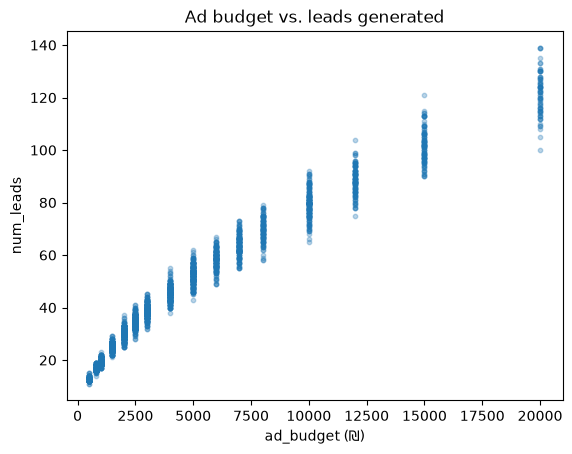

In [6]:
import matplotlib.pyplot as plt

plt.scatter(df["ad_budget"], df["num_leads"], alpha=0.3, s=10)
plt.xlabel("ad_budget (₪)")
plt.ylabel("num_leads")
plt.title("Ad budget vs. leads generated")
plt.show()

**Finding:** the relationship is close to linear/proportional across most of the
range, with only a mild flattening at the top budget levels (₪15,000 → ₪20,000).
So more budget does buy roughly proportionally more leads — the real story, as the
next section shows, is what happens to those leads afterwards, not how many arrive.

## Conversion rate by budget tier

`pd.cut` splits `ad_budget` into named buckets. Conversion rate is `closed / num_leads`
per row, then averaged per tier.

**Note on tier boundaries:** the brief defines Low (≤1500), Mid (2000–5000), and
High (>5000) — leaving ₪1500–2000 undefined. Rather than silently folding those rows
into Low or Mid (which would quietly change both tiers' numbers), they are kept in
their own bucket so the gap in the brief's own definition stays visible.

In [7]:
tier = pd.cut(
    df["ad_budget"],
    bins=[0, 1500, 2000, 5000, float("inf")],
    labels=["Low (<=1500)", "Unclassified (1500-2000)", "Mid (2000-5000)", "High (>5000)"],
)
conversion_rate = df["closed"] / df["num_leads"]

conversion_rate.groupby(tier, observed=True).mean().sort_index()

ad_budget
Low (<=1500)                0.045242
Unclassified (1500-2000)    0.072228
Mid (2000-5000)             0.085323
High (>5000)                0.054335
dtype: float64

**Finding — this is the headline result of Package 1:** conversion rate does **not**
rise with budget. **Mid (2000–5000) converts best at 8.5%**, while **High (>5000)
converts worse, at 5.4%** — barely better than Low. Bigger ad spend buys proportionally
more leads (previous section), but not proportionally better ones. That is direct,
data-driven evidence for the founder's suspicion that ad spend is not being optimized
on evidence.